# Pregunta 2


In [48]:
%pip install opencv-python matplotlib numpy
import cv2
import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


El calculo de histograma se hizo con la función histogram de numpy, que devuelve  el conteo de pixeles (porque ignoramos el segundo dato que devuelve que son los bordes)
region es la zona donde se calculará el histograma



In [49]:
def histograma(region):#especifico los niveles en 256 que sirve para el formato de 8 bits
    hist, _ = np.histogram(region, 256, (0, 256))
    return hist.astype(np.float64)

Ahora defino su Look Up Table, que me permite relacionar el tono original con el nuevo valor ecualizado, así no se debe calcular la fórmula pixel a pixel

In [50]:
def LUTs(region, limite=None):
    #devuelve el conteo de pixeles de la region
    hist = histograma(region)

    #acá se aplica la idea de CLAHE, donde se limita el contraste si se define un limite 
    if limite is not None:
        extra = 0
        #va revisando todos los niveles e ignora los que se salen del límite establecido
        for i in range(256):
            if hist[i] > limite:
                extra += hist[i] - limite
                hist[i] = limite
        #cuando se recortan los peaks para evitar ese contraste exagerado, sobran esos pixeles,
        #pero no se pueden borrar o pierdo información así que se dividen y reparten equitativamente reduciendo el contraste
        division = extra / 256
        for i in range(256):
            hist[i] += division


    #Si no se aplica un limite, no se cambia el histograma, es una ecualización local pura
    #Ahora si se calcula la CDF (que es la funcion de deistribución acumulada) con la fórmula de siempre
    lut = np.zeros(256)
    pixelestotales = region.size
    acumulado = 0
    #
    for i in range(256):
        acumulado += hist[i]
        lut[i] = round((acumulado / pixelestotales) * 255)

    return lut

Finalmente junto todo en el ecualizador, que agrupa la formación de mallas , la aplicacion de las luts y el interpolado para una correcta visualización de la imagen de salida

In [51]:
def ecualizador(imagen, region, limite, separacion):
    #primeo defino las dimensiones de la imagen a través de shape y 
    # como quiero revisar al rededor de un punto defino mi radio que  me ayudará a seleccionar la region
    alto, ancho = imagen.shape
    radio = int(region / 2)

    #malla de centros, que va a depender de la separacion que decida tomar
    #si la separacion es 10, los centros iran de 0, 20, 30, etc
    ycentro = list(range(0, alto, separacion))
    xcentro = list(range(0, ancho, separacion))
    filcentros = len(ycentro)
    colcentros = len(xcentro)

    #un LUT por centro
    luts = np.zeros((filcentros, colcentros, 256))
    for i in range(filcentros):
        for j in range(colcentros):
            cy = ycentro[i]
            cx = xcentro[j]

            # para no salirse de la imagen
            y0 = max(0, cy - radio)
            y1 = min(alto, cy + radio)
            x0 = max(0, cx - radio)
            x1 = min(ancho, cx + radio)

            #a mi lut le paso el pedazo de imagen recortado en el centro cy y cx
            luts[i, j] = LUTs(imagen[y0:y1, x0:x1], limite)

    # aplicarlo a cada pixel
    salida = np.zeros((alto, ancho))
    for i in range(alto):
        for j in range(ancho):

            # calcular centros
            if filcentros > 1:
                iy1 = min(int(i / separacion), filcentros - 2)
                iy2 = iy1 + 1
            else:
                iy1 = 0
                iy2 = 0
            if colcentros > 1:
                ix1 = min(int(j / separacion), colcentros - 2)
                ix2 = ix1 + 1
            else:
                ix1 = 0
                ix2 = 0

            y1 = ycentro[iy1]
            y2 = ycentro[iy2]
            x1 = xcentro[ix1]
            x2 = xcentro[ix2]
            nivel = imagen[i, j]

            # leo el valor que cada una de las 4 LUTs vecinas le daria a este nivel
            f11 = luts[iy1, ix1, nivel]
            f21 = luts[iy1, ix2, nivel]
            f12 = luts[iy2, ix1, nivel]
            f22 = luts[iy2, ix2, nivel]

            # interpolacion para que quede suave el resultado
            if x2 != x1:
                fy1 = f11 + (f21 - f11) / (x2 - x1) * (j - x1)
                fy2 = f12 + (f22 - f12) / (x2 - x1) * (j - x1)
            else:
                fy1, fy2 = f11, f12

            if y2 != y1:
                valor = fy1 + (fy2 - fy1) / (y2 - y1) * (i - y1)
            else:
                valor = fy1


            #esto es para no salirme del rango
            if valor > 255:
                valor = 255
            if valor < 0:
                valor = 0
            salida[i, j] = valor

    return salida.astype(np.uint8)

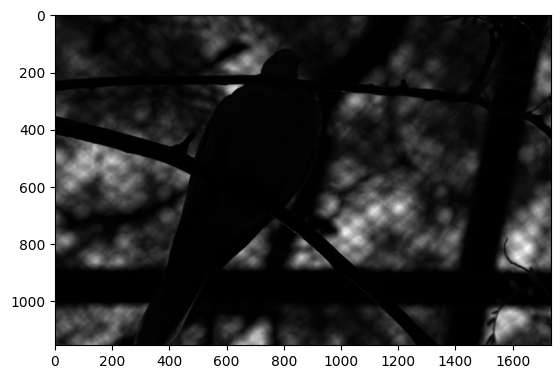

In [52]:
#Primero cargo la imágen para asegurarme que todo esté bien
imagen = cv2.imread('P2_IMG_2423.tif', cv2.IMREAD_GRAYSCALE)
plt.imshow(imagen, cmap="gray")

 Seleccione una región aproximadamente homogénea y explique, usando su histograma y su
CDF, por qué una ecualización local no limitada puede amplificar ruido o pequeñas
fluctuaciones.


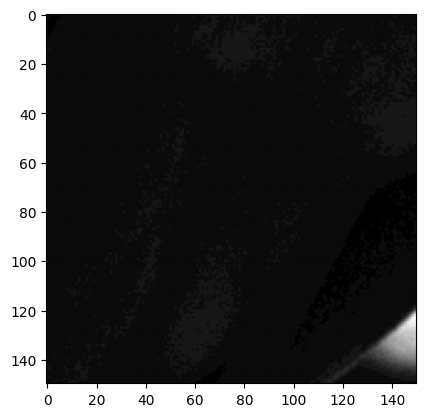

In [53]:
recorte = imagen[750:900, 450:600] #busco una zona con colores parejos
plt.imshow(recorte, cmap='gray')
plt.show()

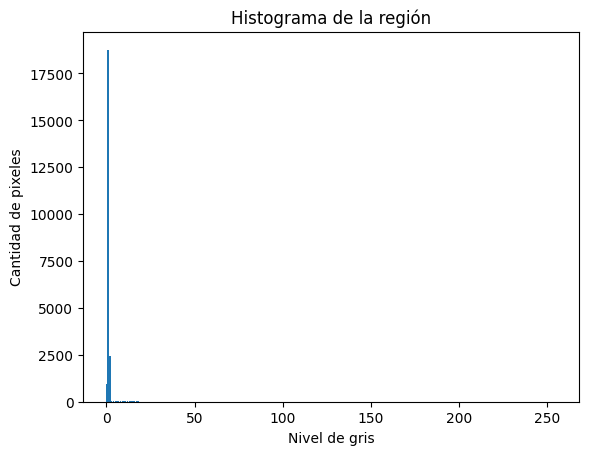

In [54]:
hist = histograma(recorte)
pixelestotales = recorte.size
plt.bar(range(256), hist)
plt.title('Histograma de la región')
plt.xlabel('Nivel de gris')
plt.ylabel('Cantidad de pixeles')
plt.show()

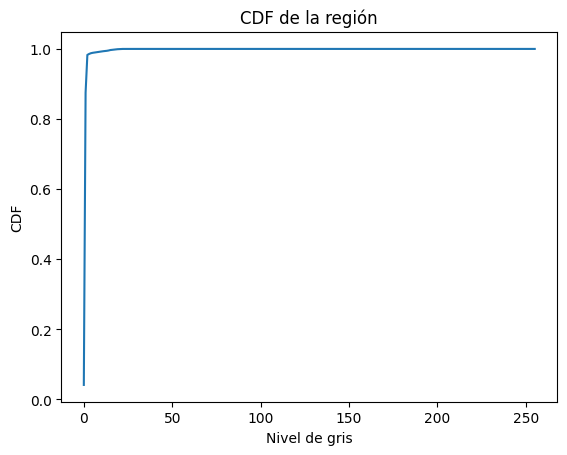

In [55]:
cdf = np.zeros(256)
acumulado = 0
for i in range(256):
    acumulado += hist[i]
    cdf[i] = acumulado / pixelestotales
plt.plot(cdf)
plt.title('CDF de la región')
plt.xlabel('Nivel de gris')
plt.ylabel('CDF')
plt.show()

## Experimentación y análisis

1-


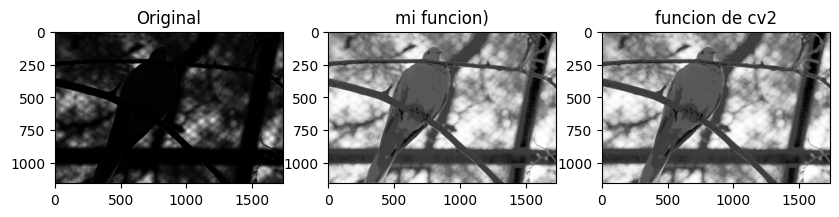

In [59]:
alto, ancho = imagen.shape
region = 2 * max(alto, ancho) 

mimodo = ecualizador(imagen,region, None, region)
yahecha = cv2.equalizeHist(imagen)

plt.figure(figsize=(10,5))
plt.subplot(1,3,1); plt.imshow(imagen, cmap='gray'); plt.title('Original')
plt.subplot(1,3,2); plt.imshow(mimodo, cmap='gray'); plt.title('mi funcion)')
plt.subplot(1,3,3); plt.imshow(yahecha, cmap='gray'); plt.title('funcion de cv2')
plt.show()

2-

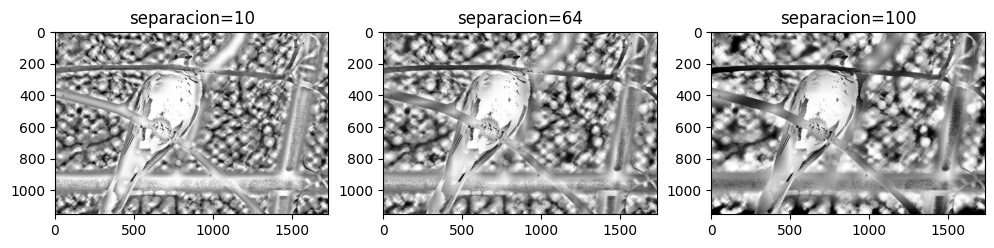

In [62]:
region = 64

resultado1 = ecualizador(imagen, region=region, limite=None, separacion=10)
resultado2 = ecualizador(imagen, region=region, limite=None, separacion=64)
resultado3 = ecualizador(imagen, region=region, limite=None, separacion=100)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(resultado1, cmap='gray'); plt.title('separacion=10')
plt.subplot(1,3,2); plt.imshow(resultado2, cmap='gray'); plt.title('separacion=64')
plt.subplot(1,3,3); plt.imshow(resultado3, cmap='gray'); plt.title('separacion=100')
plt.show()